# **Data Manager**


*   Load CSV
*   reshape to images
*   normalize
*   train/val/test split



### Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')
import os
np.random.seed(42)                   # Set NumPy random seed for reproducibility
import hashlib

### Load Data From Drive

In [ ]:
from google.colab import drive
drive.mount('/drive')

CSV_PATH = "/drive/MyDrive/ML/A_Z Handwritten Data.csv"

# Confirm full file
size_mb = os.path.getsize(CSV_PATH) / 1e6
print(f"File size: {size_mb:.1f} MB")

Mounted at /drive
File size: 698.9 MB


In [ ]:
SAVE_DIR = "/drive/MyDrive/ML/processed_data/"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
df     = pd.read_csv(CSV_PATH, header=None)
labels = df.iloc[:, 0].values.astype(np.uint8)
pixels = df.iloc[:, 1:].values.astype(np.float32)
print(f"Raw shape  : {df.shape}")
print(f"Label range: {labels.min()} – {labels.max()}")

Raw shape  : (372451, 785)
Label range: 0 – 25


### Separate labels and pixel values

In [ ]:
labels  = df.iloc[:, 0].values.astype(np.uint8)
pixels  = df.iloc[:, 1:].values.astype(np.float32)

print(f"\nLabels shape : {labels.shape}")
print(f"Pixels shape : {pixels.shape}")
print(f"Unique labels: {np.unique(labels)}")


Labels shape : (372451,)
Pixels shape : (372451, 784)
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]


### Reshape: (N, 784) → (N, 28, 28, 1)

In [ ]:
IMG_H, IMG_W = 28, 28

images = pixels.reshape(-1, IMG_H, IMG_W, 1)

print(f"\nImages shape : {images.shape}")
print(f"Pixel range  : [{images.min():.0f}, {images.max():.0f}]")


Images shape : (372451, 28, 28, 1)
Pixel range  : [0, 255]


### Normalize

In [ ]:
images = images / 255.0

print(f"After normalize: [{images.min():.2f}, {images.max():.2f}]")

After normalize: [0.00, 1.00]


### Save Data For EDA

In [ ]:
# np.savez_compressed(
#     SAVE_DIR + "az_dataset_full.npz",
#     images=images,
#     labels=labels
# )

### Sanity check — visualise samples

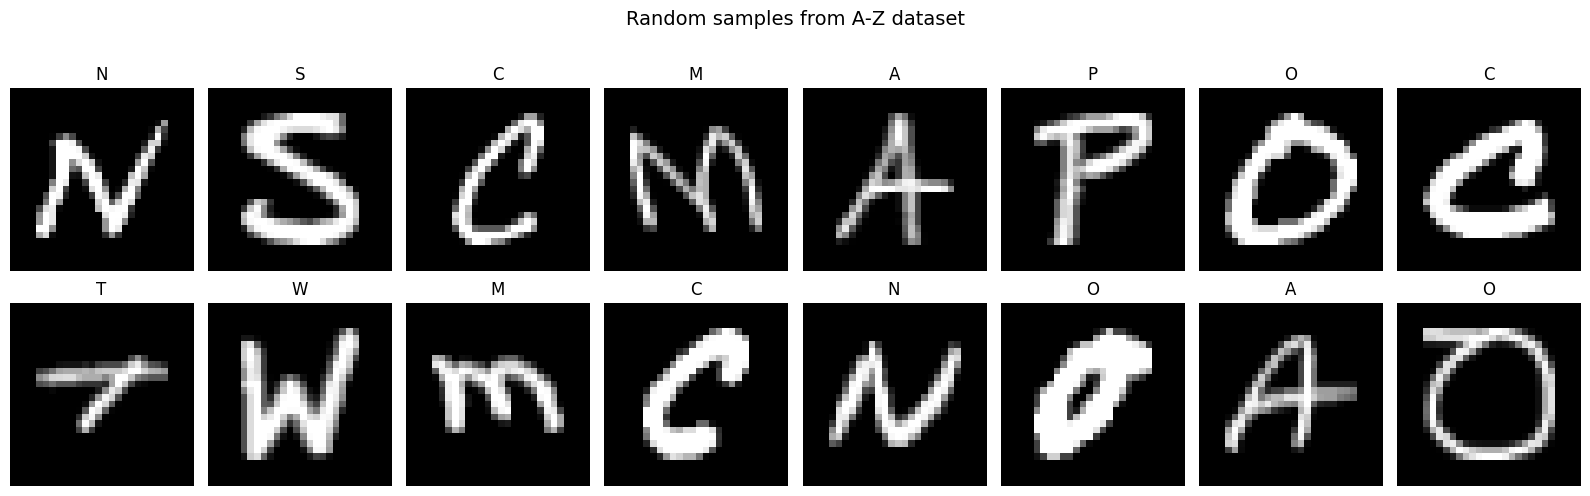

In [ ]:
LETTER_MAP = {i: chr(65 + i) for i in range(26)}

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for ax, idx in zip(axes.flatten(), np.random.choice(len(images), 16, replace=False)):
    ax.imshow(images[idx].squeeze(), cmap="gray")
    ax.set_title(LETTER_MAP[labels[idx]], fontsize=12)
    ax.axis("off")
plt.suptitle("Random samples from A-Z dataset", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### distribution

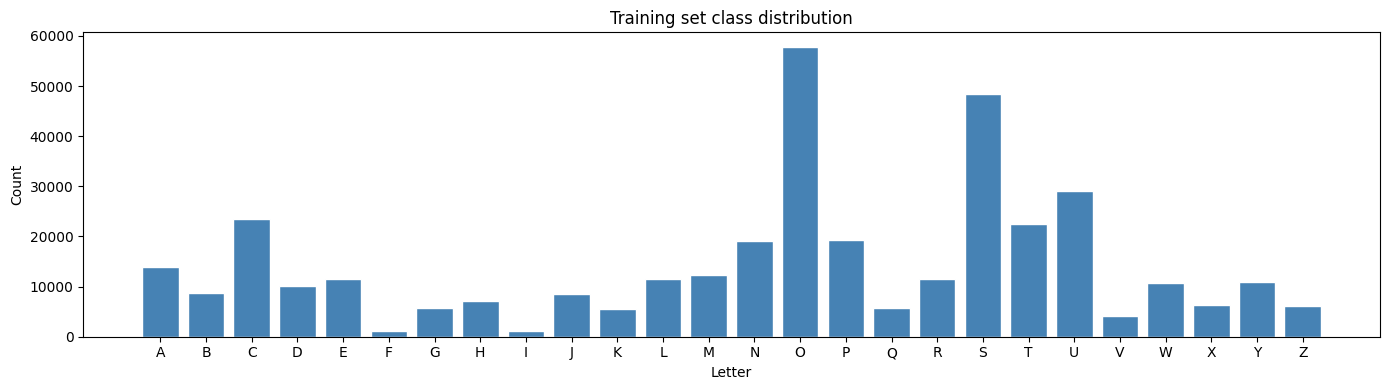

In [ ]:
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(14, 4))
plt.bar([LETTER_MAP[i] for i in unique], counts, color="steelblue", edgecolor="white")
plt.xlabel("Letter")
plt.ylabel("Count")
plt.title("Training set class distribution")
plt.tight_layout()
plt.show()

### Duplicates Handling

In [ ]:
#Duplicate check
print("Checking for duplicate images\n")
# Flatten each image to a 1D vector for hashing
X_flat = images.reshape(len(images), -1)
# Hash every image row
hashes = [hash(row.tobytes()) for row in X_flat]
total        = len(hashes)
unique_count = len(set(hashes))
duplicates   = total - unique_count
print(f"Total images     : {total:,}")
print(f"Unique images    : {unique_count:,}")
print(f"Duplicate images : {duplicates:,}")
if duplicates == 0:
    print("\nNo duplicates found — every image is unique.")
else:
    print(f"\n{duplicates:,} duplicates detected!")

Checking for duplicate images

Total images     : 372,451
Unique images    : 201,096
Duplicate images : 171,355

171,355 duplicates detected!


In [ ]:
#Remove duplicates
def hash_image(img):
    return hashlib.md5(img.tobytes()).hexdigest()
seen = set()
unique_indices = []
for i, img in enumerate(images):
    h = hash_image(img)
    if h not in seen:
        seen.add(h)
        unique_indices.append(i)

images_clean = images[unique_indices]
labels_clean = labels[unique_indices]
print("Before:", len(images))
print("After :", len(images_clean))

Before: 372451
After : 201096


###  Train / Validation / Test split  (70 / 15 / 15)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    images_clean, labels_clean,
    test_size=0.30,
    random_state=42,
    stratify=labels_clean,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
)
print("\n── Split summary ───────────────────────────")
print(f"Train : X={X_train.shape}  y={y_train.shape}")
print(f"Val   : X={X_val.shape}    y={y_val.shape}")
print(f"Test  : X={X_test.shape}   y={y_test.shape}")


── Split summary ───────────────────────────
Train : X=(140767, 28, 28, 1)  y=(140767,)
Val   : X=(30164, 28, 28, 1)    y=(30164,)
Test  : X=(30165, 28, 28, 1)   y=(30165,)


In [ ]:
np.savez_compressed(
    SAVE_DIR + "az_dataset_splits.npz",
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test
)

## Data Sanity Check Summary

This section verifies that the dataset has been correctly processed, saved, and split for downstream tasks such as EDA and model training.

### Files Check
- Confirmed that processed dataset files exist:
  - `az_dataset_full.npz`
  - `az_dataset_splits.npz`

### Full Dataset
- Images shape: `(N, 28, 28, 1)`
- Labels shape: `(N,)`
- Number of samples in images matches labels
- Pixel values are normalized between 0 and 1
- Data format is consistent for visualization and EDA

### Data Splits
- Training, validation, and test sets loaded successfully
- Input-output pairs are aligned:
  - `X_train` with `y_train`
  - `X_val` with `y_val`
  - `X_test` with `y_test`

### Shape Consistency
- All splits share the same input shape `(28, 28, 1)`
- No dimensional mismatches across datasets

### Split Ratios
- Training set: approximately 70%
- Validation set: approximately 15%
- Test set: approximately 15%
- Ratios are within acceptable tolerance

### Labels Check
- Multiple unique classes detected
- Dataset is suitable for classification tasks

### Conclusion
The dataset is correctly preprocessed, normalized, and split.  
All sanity checks passed, and the data is ready for exploratory data analysis and model training.
